In [ ]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import pathlib
import mne
from mne.preprocessing import (ICA, create_eog_epochs, create_ecg_epochs)
import warnings
warnings.filterwarnings('ignore')

In [28]:
raw = mne.io.read_raw_eeglab('subj018.set', preload=False)
'''raw_reref = raw.set_eeg_reference(ref_channels='average', ch_type='eeg')''' # not doing reref for this testing phase

tmin, tmax, baseline = -0.1, 1, None
events, event_id = mne.events_from_annotations(raw)

epochs = mne.Epochs(raw, events=events, event_id=event_id,
                    flat=None, reject=None, reject_by_annotation=False, tmin=tmin, tmax=tmax, baseline=baseline, preload=False)
epochs_data = epochs.get_data()[:,:,0:1100]
print(epochs_data.shape)

Reading C:\Users\amand\BrainHack\subj018.fdt
Used Annotations descriptions: ['1', '10', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '11', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '12', '120', '121', '122', '123', '124', '125', '126', '127', '128', '129', '13', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139', '14', '140', '141', '142', '143', '144', '145', '146', '147', '148', '149', '15', '150', '151', '152', '153', '154', '155', '156', '157', '158', '159', '16', '160', '161', '162', '163', '164', '165', '166', '167', '168', '169', '17', '170', '171', '172', '173', '174', '175', '176', '177', '178', '179', '18', '180', '181', '182', '183', '184', '185', '186', '187', '188', '189', '19', '190', '191', '192', '193', '194', '195', '196', '197', '198', '199', '2', '20', '200', '201', '202', '203', '204', '205', '206', '207', '208', '21', '210', '22', '220', '23', '24', '240', '241', '242', '243', '244', '245', '246

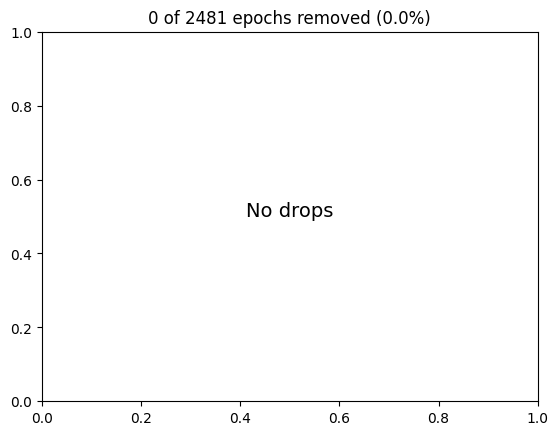

In [30]:
from mne.viz import plot_drop_log
plot_drop_log(epochs.drop_log);

## I think I might've created a Moving-Window Peak-to-Peak method in Python
But at the moment it only works for one single channel, e.g., VEOG;
will work on looping over other channels to fully detect eye movements

In [72]:
from collections import OrderedDict
from collections import namedtuple

# Wrapping it all up into a function
def MWPtP(raw, epochs, ecodes, tmin, tmax, baseline, channel, step, win, thresh):   # ecodes must be a list of strings
    ch_list = raw.ch_names
    ch_dict = OrderedDict()
    for i in range(len(ch_list)): ch_dict.update({ch_list[i]: i})
    
    epochs_data = epochs.get_data()[:,:,0:int(1000*(tmax-tmin))]
    num_epochs, num_time = epochs_data.shape[0], epochs_data.shape[2]
    
    moves = int(1+(num_time-win)/step)
    ptps = np.empty((num_epochs, moves))
    for ep in range(num_epochs):
        for t in range(moves):
            move_win = epochs_data[ep, ch_dict[channel], step*t:step*t+win].copy().reshape((win))
            ptps[ep, t] = max(move_win)-min(move_win)
    
    raw_annot = raw.annotations
    description = np.array([raw_annot[i]['description'] for i in range(len(raw_annot))])
    
    indices = [i for i,x in enumerate(description) if x in ecodes ]  
    
    new_description = ['bad' if x in ecodes and len(np.where(ptps[indices.index(i)]>thresh)[0]) != 0 else x
                        for i, x in enumerate(description)]
    
    new_annot = mne.Annotations(np.array([raw_annot[j]['onset'] for j in range(len(raw_annot))]),
                            np.zeros(len(raw_annot)),
                            new_description,
                            orig_time=None, ch_names=None)

    new_raw = raw.copy().set_annotations(new_annot)
    events, event_id = mne.events_from_annotations(new_raw)
    
    new_epochs = mne.Epochs(new_raw, events, [event_id[k] for k in ecodes] , tmin, tmax, baseline=baseline,
                            reject_by_annotation=True)
    
    Epochs_Descriptions = namedtuple('Epochs_Descriptions', ['epochs', 'descriptions'])
    epochs_descriptions = Epochs_Descriptions(new_epochs, new_description)
    return epochs_descriptions

In [73]:
from bdf_compiler import *
S1_raw = mne.io.read_raw_eeglab('S1.set', preload=False)
S1_new_raw = raw_revised(S1_raw, 'S1_BDF.txt')
S1_new_epochs = bin_based_epoch(S1_raw, 'S1_BDF.txt', tmin=-0.1, tmax=1, bc=None)

Reading C:\Users\amand\BrainHack\S1.fdt
Used Annotations descriptions: ['1', '10', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '11', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '12', '120', '121', '122', '123', '124', '125', '126', '127', '128', '129', '13', '130', '131', '132', '133', '134', '135', '136', '14', '15', '16', '17', '18', '19', '199', '2', '20', '201', '202', '203', '204', '205', '206', '207', '208', '209', '21', '210', '22', '221', '222', '23', '230', '24', '240', '25', '250', '251', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '5', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '6', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '7', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '8', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '9', '90', '91', '92', '93', '

In [76]:
S1_ep_des = MWPtP(S1_new_raw, S1_new_epochs, ecodes=[str(i) for i in range(301,305)],
               tmin=-0.1, tmax=1, baseline=None, channel='VEO', step=41, win=137, thresh=27e-6)

print('\n', S1_ep_des.epochs.get_data().shape, '\n')

f1 = open('S1_mwpp_elist.txt', 'r')
f2 = f1.readlines()
f1.close
f3 = [i.split()[8] for i in f2]

matlab_mwpp = [i for i,x in enumerate(f3) if int(x) != 0]
my_mwpp = [i for i,x in enumerate(S1_ep_des.descriptions) if x == 'bad']
if matlab_mwpp == my_mwpp:
    print('My Moving-Window Peak-to-Peak method created from scratch is identical to that done in EEGLAB 😁')

Loading data for 256 events and 1101 original time points ...
Used Annotations descriptions: ['1', '10', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '11', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '12', '120', '121', '122', '123', '124', '125', '126', '127', '128', '129', '13', '130', '131', '132', '133', '134', '135', '136', '14', '15', '16', '17', '18', '19', '199', '2', '20', '201', '202', '203', '204', '205', '206', '207', '208', '209', '21', '210', '22', '221', '222', '23', '230', '24', '240', '25', '250', '251', '26', '27', '28', '29', '3', '30', '301', '302', '303', '304', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '5', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '6', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '7', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '8', '80', '81', '82', '83', '84', '85', '86'

In [81]:
subj018_raw = mne.io.read_raw_eeglab('subj018.set', preload=False)
subj018_new_raw = raw_revised(subj018_raw, 'subj018_BDF.txt')
subj018_new_epochs = bin_based_epoch(subj018_raw, 'subj018_BDF.txt', tmin=-0.1, tmax=1, bc=None)

subj018_ep_des = MWPtP(subj018_new_raw, subj018_new_epochs, ecodes=[str(i) for i in range(301,309)],
               tmin=-0.1, tmax=1, baseline=None, channel='VEO', step=25, win=50, thresh=75e-6)

print('\n', subj018_ep_des.epochs.get_data().shape, '\n')

f1 = open('subj018_mwpp_elist.txt', 'r')
f2 = f1.readlines()
f1.close
f3 = [i.split()[8] for i in f2]

matlab_mwpp = [i for i,x in enumerate(f3) if int(x) != 0]
my_mwpp = [i for i,x in enumerate(subj018_ep_des.descriptions) if x == 'bad']
if matlab_mwpp == my_mwpp:
    print('My Moving-Window Peak-to-Peak method is identical to that done in EEGLAB — again!!!😍')

Reading C:\Users\amand\BrainHack\subj018.fdt
Used Annotations descriptions: ['1', '10', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '11', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '12', '120', '121', '122', '123', '124', '125', '126', '127', '128', '129', '13', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139', '14', '140', '141', '142', '143', '144', '145', '146', '147', '148', '149', '15', '150', '151', '152', '153', '154', '155', '156', '157', '158', '159', '16', '160', '161', '162', '163', '164', '165', '166', '167', '168', '169', '17', '170', '171', '172', '173', '174', '175', '176', '177', '178', '179', '18', '180', '181', '182', '183', '184', '185', '186', '187', '188', '189', '19', '190', '191', '192', '193', '194', '195', '196', '197', '198', '199', '2', '20', '200', '201', '202', '203', '204', '205', '206', '207', '208', '21', '210', '22', '220', '23', '24', '240', '241', '242', '243', '244', '245', '246